In [1]:
!pip install transformers medmnist scikit-learn torch torchvision scipy seaborn

# Notebook 4 — Evaluation

Full comparative evaluation of the three models on the held-out test set.

> **Prerequisite:** Run notebooks 02 and 03 first.

**Metrics reported:**
- AUC (Area Under the ROC Curve)
- Average Precision (area under the PR curve — most relevant for rare events)
- Accuracy, Precision, Recall at the Youden-optimal threshold
- Confusion matrices

In [2]:
import numpy as np
import torch
import pickle, os
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (roc_auc_score, accuracy_score, roc_curve,
                              precision_score, recall_score,
                              average_precision_score, precision_recall_curve,
                              confusion_matrix)

ARTIFACTS_DIR = "artifacts"
EMBEDDING_DIM = 768

with open(os.path.join(ARTIFACTS_DIR, "results.pkl"), "rb") as f:
    res = pickle.load(f)

# Load MOLECULAR_DIM from the preprocessing artifact (40 real TCGA genes)
with open(os.path.join(ARTIFACTS_DIR, "preprocessing.pkl"), "rb") as f:
    prep = pickle.load(f)
MOLECULAR_DIM = int(prep["MOLECULAR_DIM"])
cancer_genes  = prep["cancer_genes"]

results_wsi = res["results_wsi"]
results_mol = res["results_mol"]
results_mm  = res["results_mm"]
wsi_labels  = res["wsi_labels"]

models_results = {
    "WSI Only\n(Dual-Stream ABMIL)"  : results_wsi,
    "Molecular Only\n(MLP)"          : results_mol,
    "Multi-Modal THREADS\n(WSI+Mol)" : results_mm,
}
palette = {
    "WSI Only\n(Dual-Stream ABMIL)"  : "#2196F3",
    "Molecular Only\n(MLP)"          : "#FF9800",
    "Multi-Modal THREADS\n(WSI+Mol)" : "#4CAF50",
}

print(f"Results loaded.  MOLECULAR_DIM={MOLECULAR_DIM}  ({cancer_genes[0]}..{cancer_genes[-1]})")
for name, res in models_results.items():
    n = name.replace('\n', ' ')
    print(f"  {n:<36}  AUC={res['auc']:.4f}  AP={res['ap']:.4f}")

Results loaded.  MOLECULAR_DIM=40  (KRAS..SFRP1)
  WSI Only (Dual-Stream ABMIL)          AUC=0.8356  AP=0.8727
  Molecular Only (MLP)                  AUC=1.0000  AP=1.0000
  Multi-Modal THREADS (WSI+Mol)         AUC=1.0000  AP=1.0000


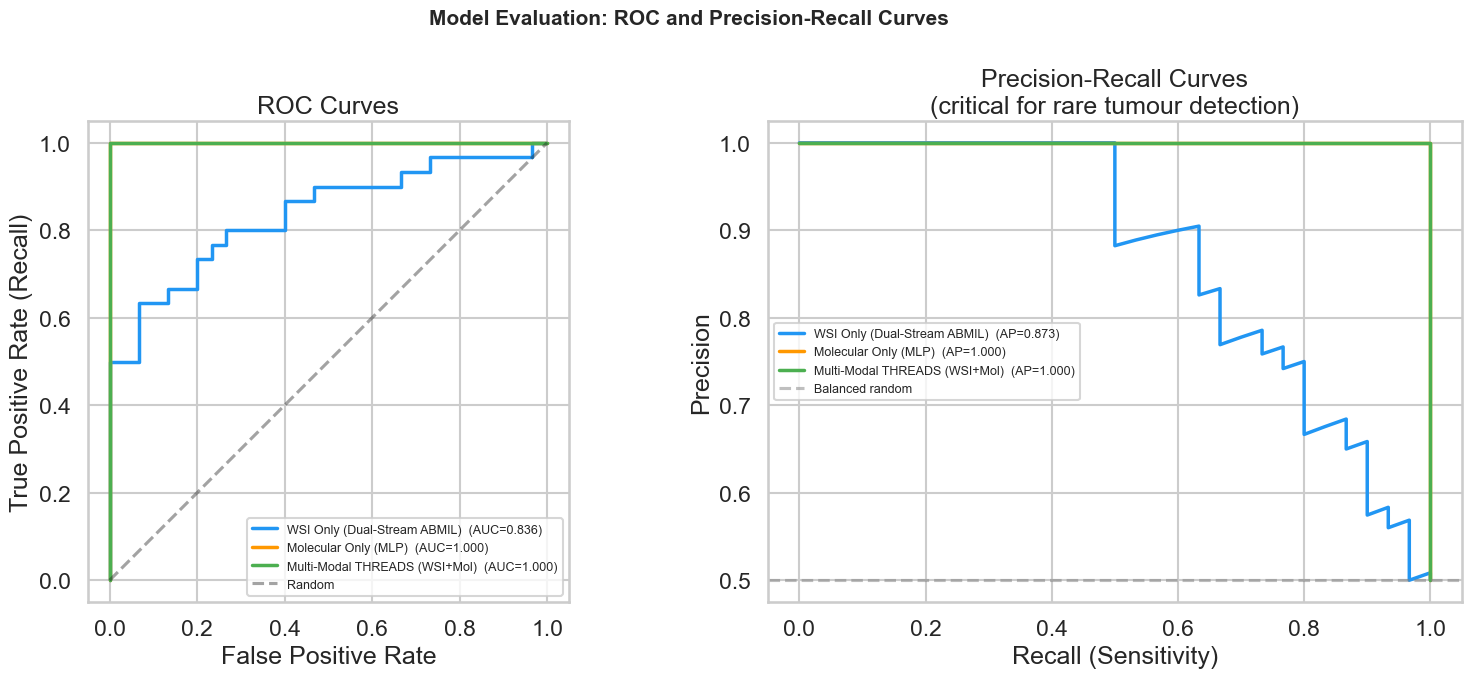

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Model Evaluation: ROC and Precision-Recall Curves",
             fontsize=15, fontweight='bold')

# ROC
ax = axes[0]
for name, res in models_results.items():
    ax.plot(res['fpr'], res['tpr'],
            label=f"{name.replace(chr(10), ' ')}  (AUC={res['auc']:.3f})",
            color=palette[name], linewidth=2.5)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curves")
ax.legend(fontsize=9, loc='lower right')
ax.set_aspect('equal')

# PR (clinically relevant for rare tumour detection)
ax = axes[1]
for name, res in models_results.items():
    p, r, _ = precision_recall_curve(res['labels'], res['preds'])
    ax.plot(r, p,
            label=f"{name.replace(chr(10), ' ')}  (AP={res['ap']:.3f})",
            color=palette[name], linewidth=2.5)
ax.axhline(0.5, color='gray', ls='--', alpha=0.5, label='Balanced random')
ax.set_xlabel("Recall (Sensitivity)")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves\n(critical for rare tumour detection)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


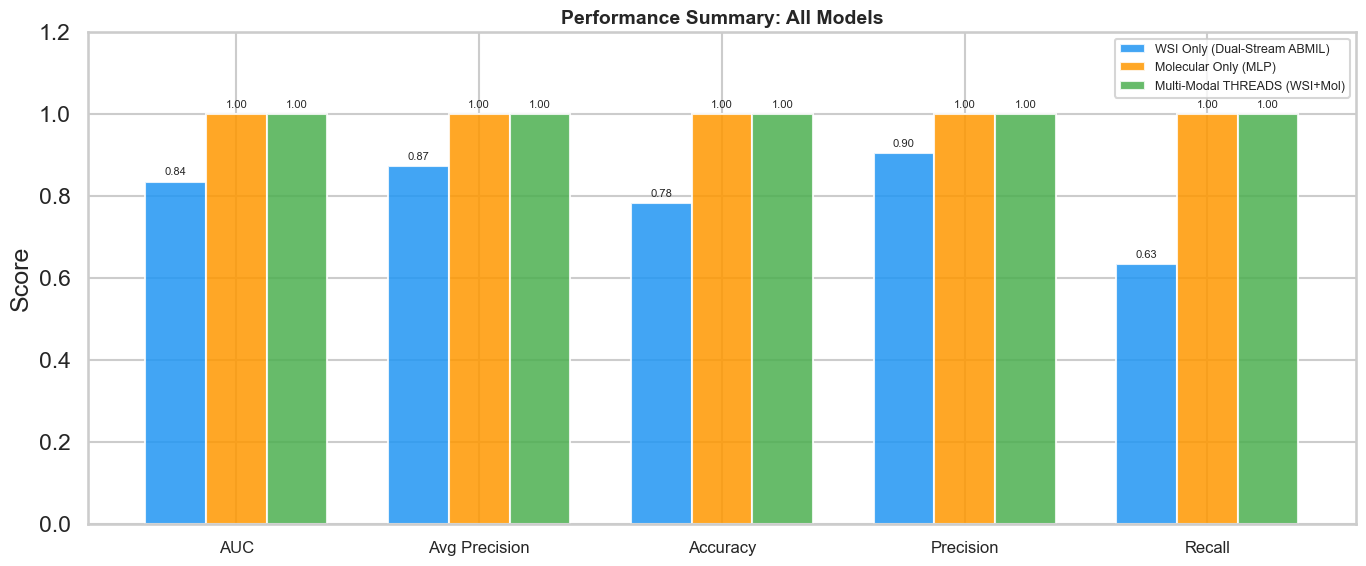


Model                                    AUC      AP       Acc      Prec       Rec
WSI Only (Dual-Stream ABMIL)          0.8356  0.8727    78.33%    90.48%    63.33%
Molecular Only (MLP)                  1.0000  1.0000   100.00%   100.00%   100.00%
Multi-Modal THREADS (WSI+Mol)         1.0000  1.0000   100.00%   100.00%   100.00%


In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title("Performance Summary: All Models", fontsize=14, fontweight='bold')

keys  = ["auc", "ap", "acc", "precision", "recall"]
xlbls = ["AUC", "Avg Precision", "Accuracy", "Precision", "Recall"]
x     = np.arange(len(keys))
w     = 0.25

for i, (name, res) in enumerate(models_results.items()):
    vals = [res[k] for k in keys]
    bars = ax.bar(x + i * w, vals, w,
                  label=name.replace('\n', ' '), color=palette[name], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{v:.2f}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + w)
ax.set_xticklabels(xlbls, fontsize=12)
ax.set_ylim(0, 1.2)
ax.set_ylabel("Score")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print(f"{'Model':<36} {'AUC':>7} {'AP':>7} {'Acc':>9} {'Prec':>9} {'Rec':>9}")
print(f"{'='*80}")
for name, res in models_results.items():
    n = name.replace('\n', ' ')
    print(f"{n:<36} {res['auc']:>7.4f} {res['ap']:>7.4f}"
          f" {res['acc']*100:>8.2f}% {res['precision']*100:>8.2f}% {res['recall']*100:>8.2f}%")
print(f"{'='*80}")


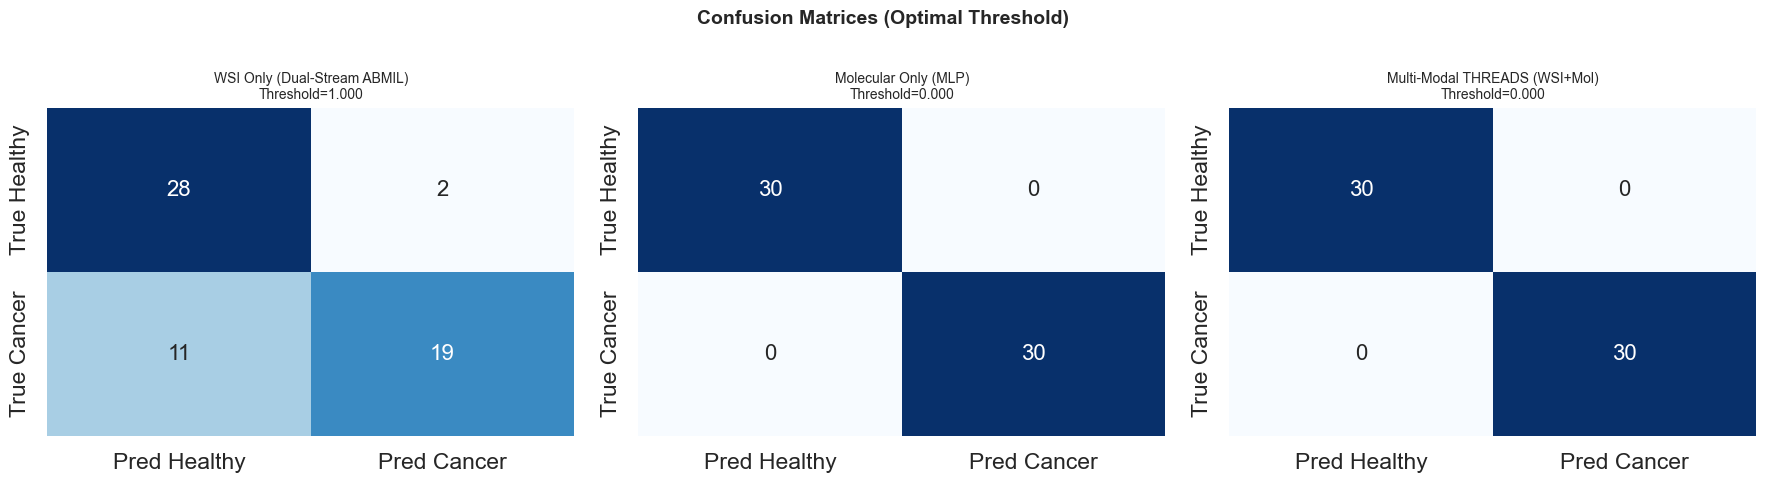

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices (Optimal Threshold)",
             fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, models_results.items()):
    binary = [1 if p >= res['threshold'] else 0 for p in res['preds']]
    cm     = confusion_matrix(res['labels'], binary)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Healthy', 'Pred Cancer'],
                yticklabels=['True Healthy', 'True Cancer'],
                cbar=False, annot_kws={'size': 16})
    ax.set_title(f"{name.replace(chr(10), ' ')}\n"
                 f"Threshold={res['threshold']:.3f}", fontsize=10)

plt.tight_layout()
plt.show()


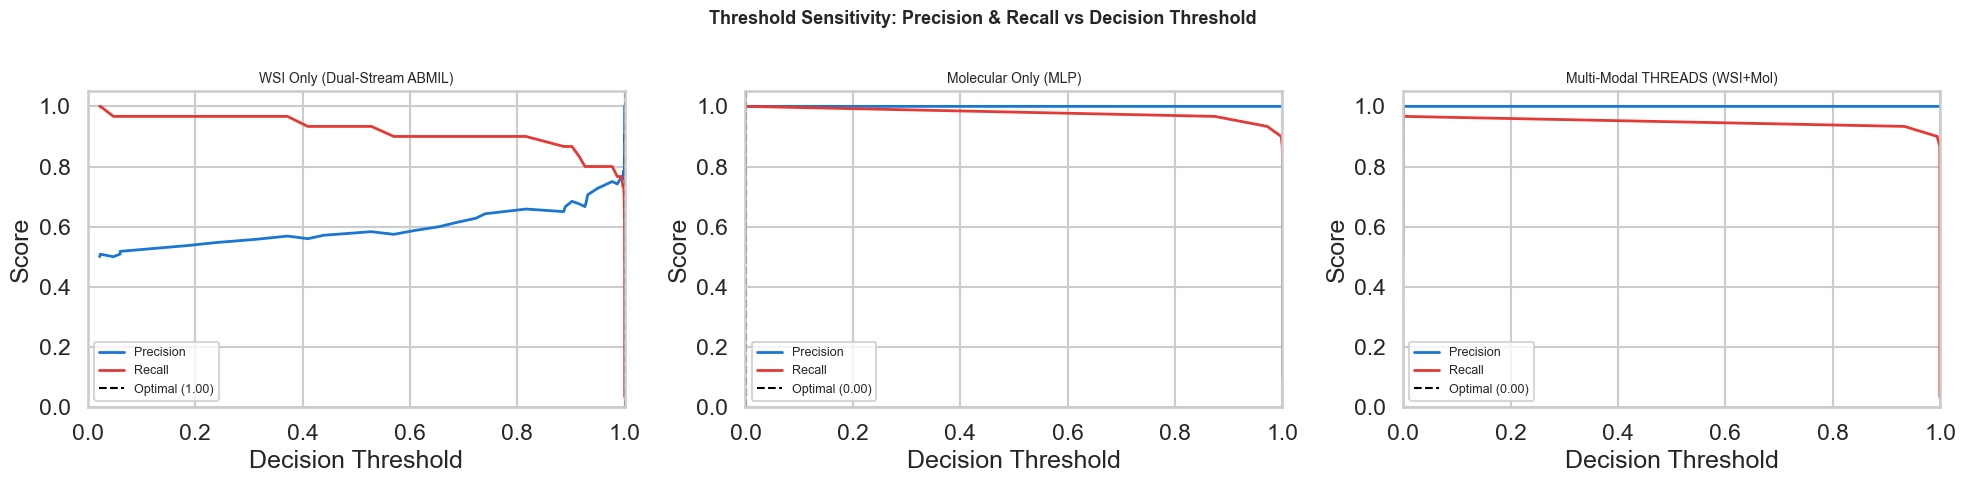

In [6]:
# ── Threshold Sensitivity Analysis ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Threshold Sensitivity: Precision & Recall vs Decision Threshold",
             fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, models_results.items()):
    p, r, thr = precision_recall_curve(res['labels'], res['preds'])
    # p and r have one more element than thr
    ax.plot(thr, p[:-1], color='#1976D2', lw=2, label='Precision')
    ax.plot(thr, r[:-1], color='#E53935', lw=2, label='Recall')
    ax.axvline(res['threshold'], color='black', ls='--', lw=1.5,
               label=f"Optimal ({res['threshold']:.2f})")
    ax.set_xlabel("Decision Threshold")
    ax.set_ylabel("Score")
    ax.set_title(name.replace('\n', ' '), fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
